In [1]:
import pandas as pd

In [2]:
datos = pd.read_csv("APhMm_matrix.csv")

In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nm       351 non-null    float64
 1   A_7_5g   351 non-null    float64
 2   A_15g    351 non-null    float64
 3   A_18g    351 non-null    float64
 4   A_22_5g  351 non-null    float64
dtypes: float64(5)
memory usage: 13.8 KB


In [4]:
datos.head()

,nm,A_7_5g,A_15g,A_18g,A_22_5g
0,231.0,0.751,1.513,1.453,2.434
1,231.5,0.743,1.494,1.437,2.386
2,232.0,0.735,1.476,1.421,2.338
3,232.5,0.726,1.459,1.404,2.293
4,233.0,0.718,1.441,1.386,2.249


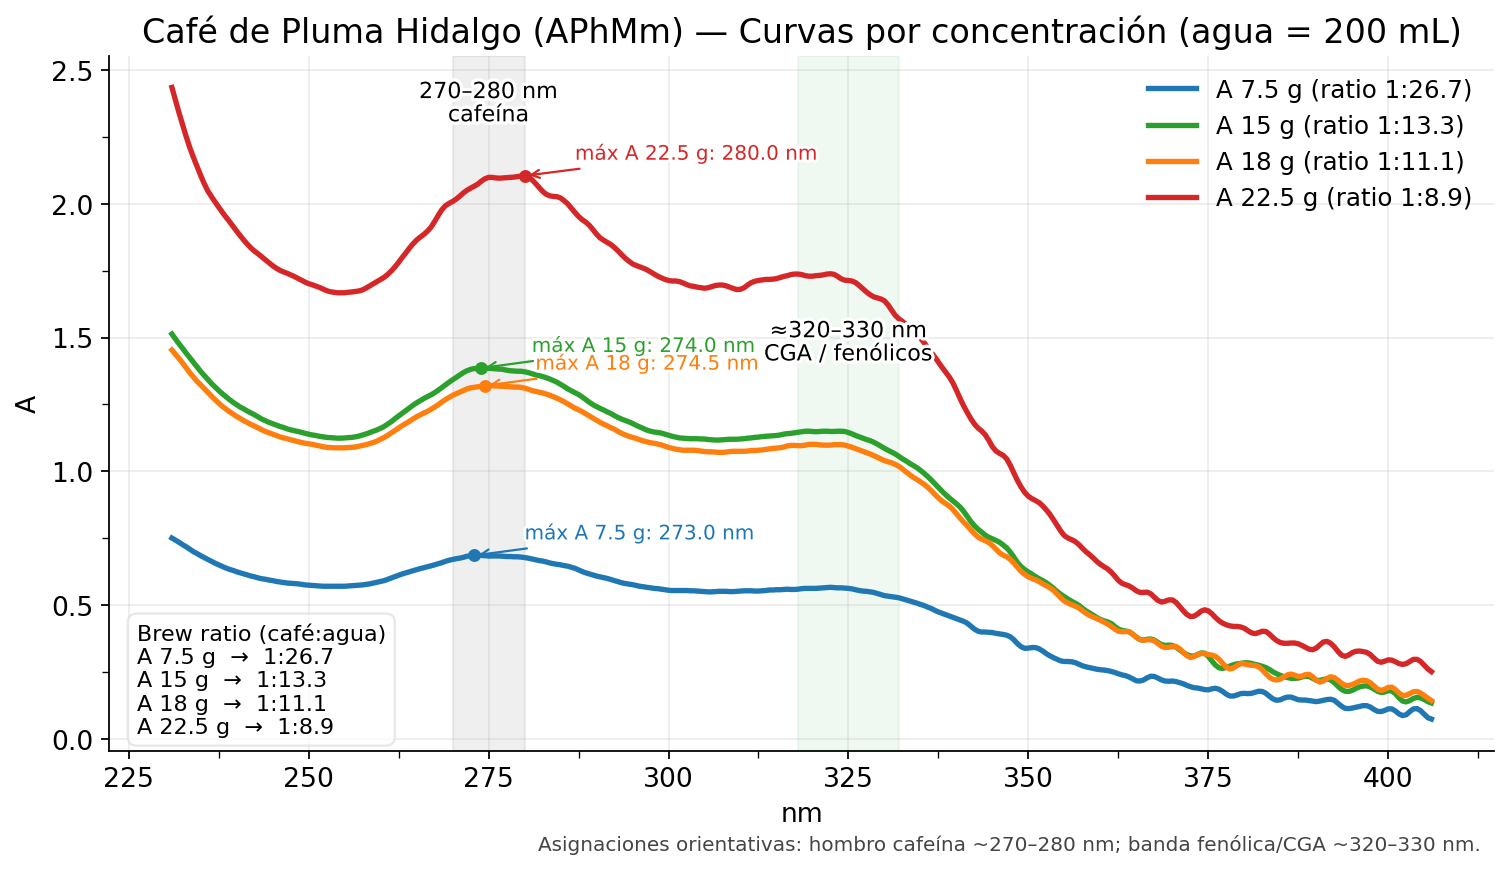

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patheffects as pe

df_plot = datos.copy()
plot_cols = ["A_7_5g", "A_15g", "A_18g", "A_22_5g"]

# ----- Parámetros de extracción -----
WATER_ML = 200.0  # mL por extracción
grams_map = {"A_7_5g": 7.5, "A_15g": 15.0, "A_18g": 18.0, "A_22_5g": 22.5}

def ratio_str(g):
    return f"1:{WATER_ML/g:.1f}"

pretty = {"A_7_5g":"A 7.5 g", "A_15g":"A 15 g", "A_18g":"A 18 g", "A_22_5g":"A 22.5 g"}
labels = {c: f"{pretty[c]} (ratio {ratio_str(grams_map[c])})" for c in plot_cols}

# Paleta consistente
colors = {"A_7_5g":"#1f77b4","A_15g":"#2ca02c","A_18g":"#ff7f0e","A_22_5g":"#d62728"}

# Estética global sobria
plt.rcParams.update({
    "figure.figsize": (9.6, 5.6),
    "figure.dpi": 160,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.23,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots()

# Curvas
for c in plot_cols:
    ax.plot(df_plot["nm"], df_plot[c], lw=2.4, label=labels[c], color=colors[c], zorder=2)

# === Bandas espectrales de interés (sombras suaves) ===
# Cafeína ~270–280 nm
ax.axvspan(270, 280, color="gray", alpha=0.12, zorder=0)
# Fenólicos/CGA ~320–330 nm
ax.axvspan(318, 332, color="#8acc9a", alpha=0.12, zorder=0)

# Etiquetas de bandas (con trazo blanco para legibilidad)
def band_label(x, y, text, color="black"):
    txt = ax.text(x, y, text, ha="center", va="center", fontsize=10, color=color, zorder=5)
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

ylim = ax.get_ylim()
band_label(275, ylim[1]*0.93, "270–280 nm\ncafeína")
band_label(325, ylim[1]*0.58, "≈320–330 nm\nCGA / fenólicos")

# === Flechas a máximos locales (260–320 nm) en cada curva ===
x = df_plot["nm"].to_numpy()
mask = (x >= 260) & (x <= 320)

def mark_local_peak(y, color, name_for_text):
    xm, ym = x[mask], y[mask]
    if not np.any(np.isfinite(ym)): return
    i = np.nanargmax(ym)
    ax.plot(xm[i], ym[i], "o", ms=4.8, color=color, zorder=6)
    ax.annotate(f"máx {name_for_text}: {xm[i]:.1f} nm",
                xy=(xm[i], ym[i]),
                xytext=(xm[i] + 7, ym[i] + 0.06),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle="->", lw=1.0, color=color),
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

for c in plot_cols:
    mark_local_peak(df_plot[c].to_numpy(dtype=float), colors[c], pretty[c])

# Ejes, ticks, leyenda
ax.set_xlabel("nm")
ax.set_ylabel("A")
ax.set_title(f"Café de Pluma Hidalgo (APhMm) — Curvas por concentración (agua = {WATER_ML:.0f} mL)")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which="minor", length=3)

leg = ax.legend(loc="upper right", frameon=False, ncol=1)

# Recuadro con ratios ordenados
rat_lines = [f"{pretty[c]:>6}  →  {ratio_str(grams_map[c])}" for c in ["A_7_5g","A_15g","A_18g","A_22_5g"]]
ax.text(0.02, 0.02, "Brew ratio (café:agua)\n" + "\n".join(rat_lines),
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="#e0e0e0", boxstyle="round,pad=0.4"))

# Nota de pie discreta (origen de asignaciones)
ax.text(0.99, -0.12,
        "Asignaciones orientativas: hombro cafeína ~270–280 nm; banda fenólica/CGA ~320–330 nm.",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#444444")

fig.tight_layout()
fig.savefig("APhMm_curvas_publicacion_pro.png", dpi=300)
plt.show()

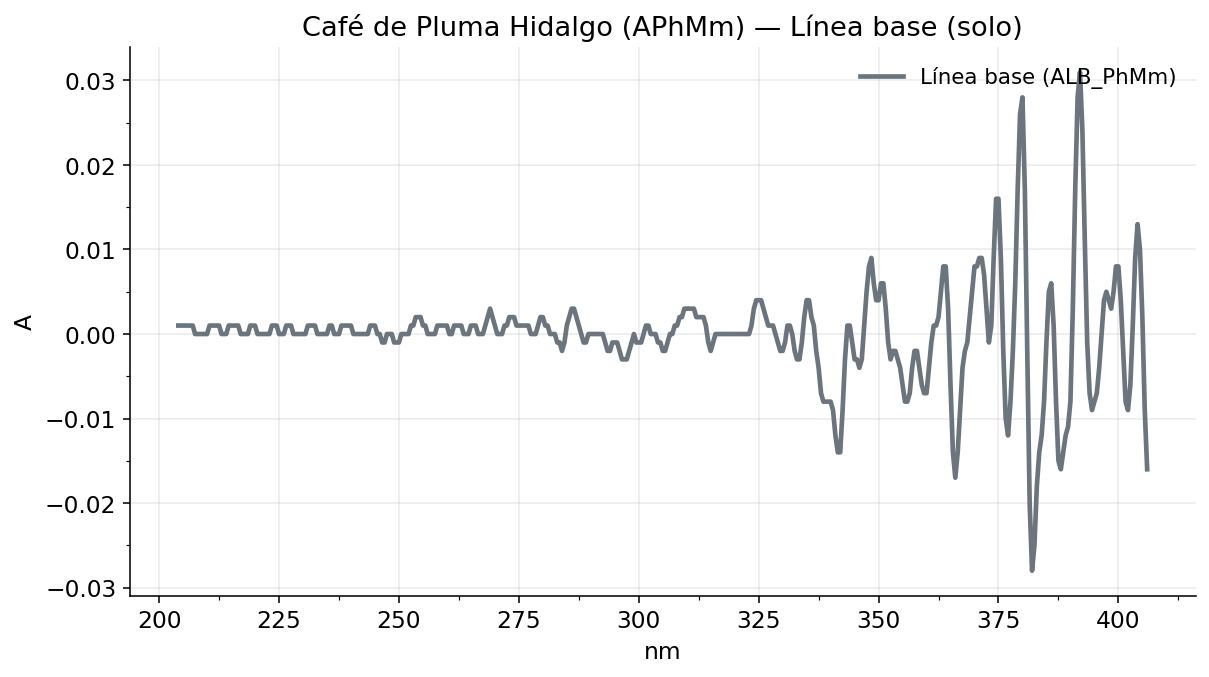

In [8]:
# === Graficar SOLO la línea base (ALB_PhMm_clean.csv) ===
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Toggle para mostrar/ocultar banda de cafeína
SHOW_CAFFEINE_BAND = False  # <— pon True si la quieres

# 1) localizar el archivo limpio de línea base (busca en subcarpetas)
candidates = list(Path(".").glob("**/ALB_PhMn_clean.csv"))
if not candidates:
    raise FileNotFoundError("No encontré ALB_PhMn_clean.csv. Revisa que ya exista el 'clean' en ALB_PhMm/")
base_csv = candidates[0]

# 2) cargar
base = pd.read_csv(base_csv)   # columnas: nm, A

# 3) estilo
plt.rcParams.update({
    "figure.figsize": (8.8, 5.0),
    "figure.dpi": 140,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# 4) plot
fig, ax = plt.subplots()
ax.plot(base["nm"], base["A"], lw=2.4, color="#6c757d", label="Línea base (ALB_PhMm)")

# (opcional) banda 270–280 nm — AHORA DESACTIVADA
if SHOW_CAFFEINE_BAND:
    ax.axvspan(270, 280, color="gray", alpha=0.12)

# formato
ax.set_xlabel("nm")
ax.set_ylabel("A")
ax.set_title("Café de Pluma Hidalgo (APhMm) — Línea base (solo)")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig("APhMm_linea_base.png", dpi=300, bbox_inches="tight")
plt.show()